# Queue Position Analysis - Understanding Fill Rate

**Purpose:** Understand why fill rate is 0.5-1.5% and what drives it.  
**Key insight from notebook 01:** All symbols have spread = 1 tick almost always.  
At 1-tick spread, κ doesn't matter - **queue position determines fills.**

## The Problem
When spread = 1 tick, every market maker quotes the same bid and ask price.  
Fill order is **price-time priority** - earlier order gets filled first.  
We joined late (GCP VM ~100ms latency) → we're near the back of the queue.

## Confirmed Columns Available
```
total_bid_qty        - total bid volume at best bid
total_ask_qty        - total ask volume at best ask  
bid_q1..bid_q5       - quantity at each bid level (bid_q1 = best bid queue)
ask_q1..ask_q5       - quantity at each ask level
bid_p1..bid_p5       - price at each bid level
ask_p1..ask_p5       - price at each ask level
tick_count           - number of ticks in this 1s bar (activity proxy)
imbalance_last       - (bid-ask)/(bid+ask), -1 to +1
imbalance_mean/std   - mean and std of imbalance in bar
imbalance_ma_10s/30s/60s - moving averages of imbalance
spread_mean/max/bps  - spread metrics
realized_vol_10s/30s/60s/300s - volatility at multiple windows
price_mom_10s/30s/60s - price momentum
price_impact         - estimated price impact
volume_delta         - buy vol - sell vol
volume_cumulative    - cumulative volume
volume_ratio         - relative volume
spread_zscore        - spread z-score vs recent history
weighted_mid         - volume-weighted mid price
```

---

## 0. Imports & Config

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gcsfs
from matplotlib.patches import Patch
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

GCP_PROJECT  = 'hedge-fund-494103'
GCS_BUCKET   = 'hedge-fund-494103-marketdata'
GCS_PREFIX   = 'processed/features'
FINDINGS_DIR = '../findings'

SYMBOLS = [
    'CHOLAFIN26MAYFUT',
    'ADANIPORTS26MAYFUT',
    'DRREDDY26MAYFUT',
    'ADANIENT26MAYFUT',
    'HAVELLS26MAYFUT',
    'JSWSTEEL26MAYFUT',
    'RELIANCE26MAYFUT',
]

DATES = ['2026-05-13', '2026-05-14', '2026-05-15']

LOT_SIZES = {
    'CHOLAFIN26MAYFUT':   625,
    'ADANIPORTS26MAYFUT': 475,
    'DRREDDY26MAYFUT':    625,
    'ADANIENT26MAYFUT':   309,
    'HAVELLS26MAYFUT':    500,
    'JSWSTEEL26MAYFUT':   675,
    'RELIANCE26MAYFUT':   500,
}

os.makedirs(FINDINGS_DIR, exist_ok=True)
print('Config loaded.')

c:\projects\quant-fund\venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Config loaded.


c:\projects\quant-fund\venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


## 1. Load Data

In [2]:
fs = gcsfs.GCSFileSystem(project=GCP_PROJECT)

def load_symbol(symbol: str, dates: list) -> pd.DataFrame:
    frames = []
    for date in dates:
        path = f"{GCS_BUCKET}/{GCS_PREFIX}/{symbol}/{date}.parquet"
        if not fs.exists(path):
            print(f'  [MISS] {symbol} / {date}')
            continue
        df = pd.read_parquet(f"gs://{path}")
        df['date'] = date
        frames.append(df)
        print(f'  [OK]   {symbol} / {date} — {len(df):,} bars')
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True).sort_values('ts_sec').reset_index(drop=True)
    out['ist_tod_sec'] = (out['ts_sec'] + 19800) % 86400
    out['ist_hhmm']    = out['ist_tod_sec'].apply(
        lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}"
    )
    return out


symbol_data = {}
for sym in SYMBOLS:
    print(f'Loading {sym}...')
    df = load_symbol(sym, DATES)
    if not df.empty:
        symbol_data[sym] = df

print(f'\nLoaded {len(symbol_data)}/{len(SYMBOLS)} symbols')

Loading CHOLAFIN26MAYFUT...
  [OK]   CHOLAFIN26MAYFUT / 2026-05-13 — 18,244 bars
  [OK]   CHOLAFIN26MAYFUT / 2026-05-14 — 17,959 bars
  [OK]   CHOLAFIN26MAYFUT / 2026-05-15 — 19,156 bars
Loading ADANIPORTS26MAYFUT...
  [OK]   ADANIPORTS26MAYFUT / 2026-05-13 — 19,859 bars
  [OK]   ADANIPORTS26MAYFUT / 2026-05-14 — 19,188 bars
  [OK]   ADANIPORTS26MAYFUT / 2026-05-15 — 19,876 bars
Loading DRREDDY26MAYFUT...
  [OK]   DRREDDY26MAYFUT / 2026-05-13 — 20,205 bars
  [OK]   DRREDDY26MAYFUT / 2026-05-14 — 11,551 bars
  [OK]   DRREDDY26MAYFUT / 2026-05-15 — 11,579 bars
Loading ADANIENT26MAYFUT...
  [OK]   ADANIENT26MAYFUT / 2026-05-13 — 17,422 bars
  [OK]   ADANIENT26MAYFUT / 2026-05-14 — 20,602 bars
  [OK]   ADANIENT26MAYFUT / 2026-05-15 — 20,682 bars
Loading HAVELLS26MAYFUT...
  [OK]   HAVELLS26MAYFUT / 2026-05-13 — 18,068 bars
  [OK]   HAVELLS26MAYFUT / 2026-05-14 — 17,384 bars
  [OK]   HAVELLS26MAYFUT / 2026-05-15 — 18,390 bars
Loading JSWSTEEL26MAYFUT...
  [OK]   JSWSTEEL26MAYFUT / 2026-05-1

## 2. Best Bid Queue Depth (bid_q1)

`bid_q1` = quantity sitting at the best bid price — the exact queue we compete in.  
To get filled, a market sell order must clear through everyone ahead of us in this queue.  
**Shallower bid_q1 = better fill probability.**

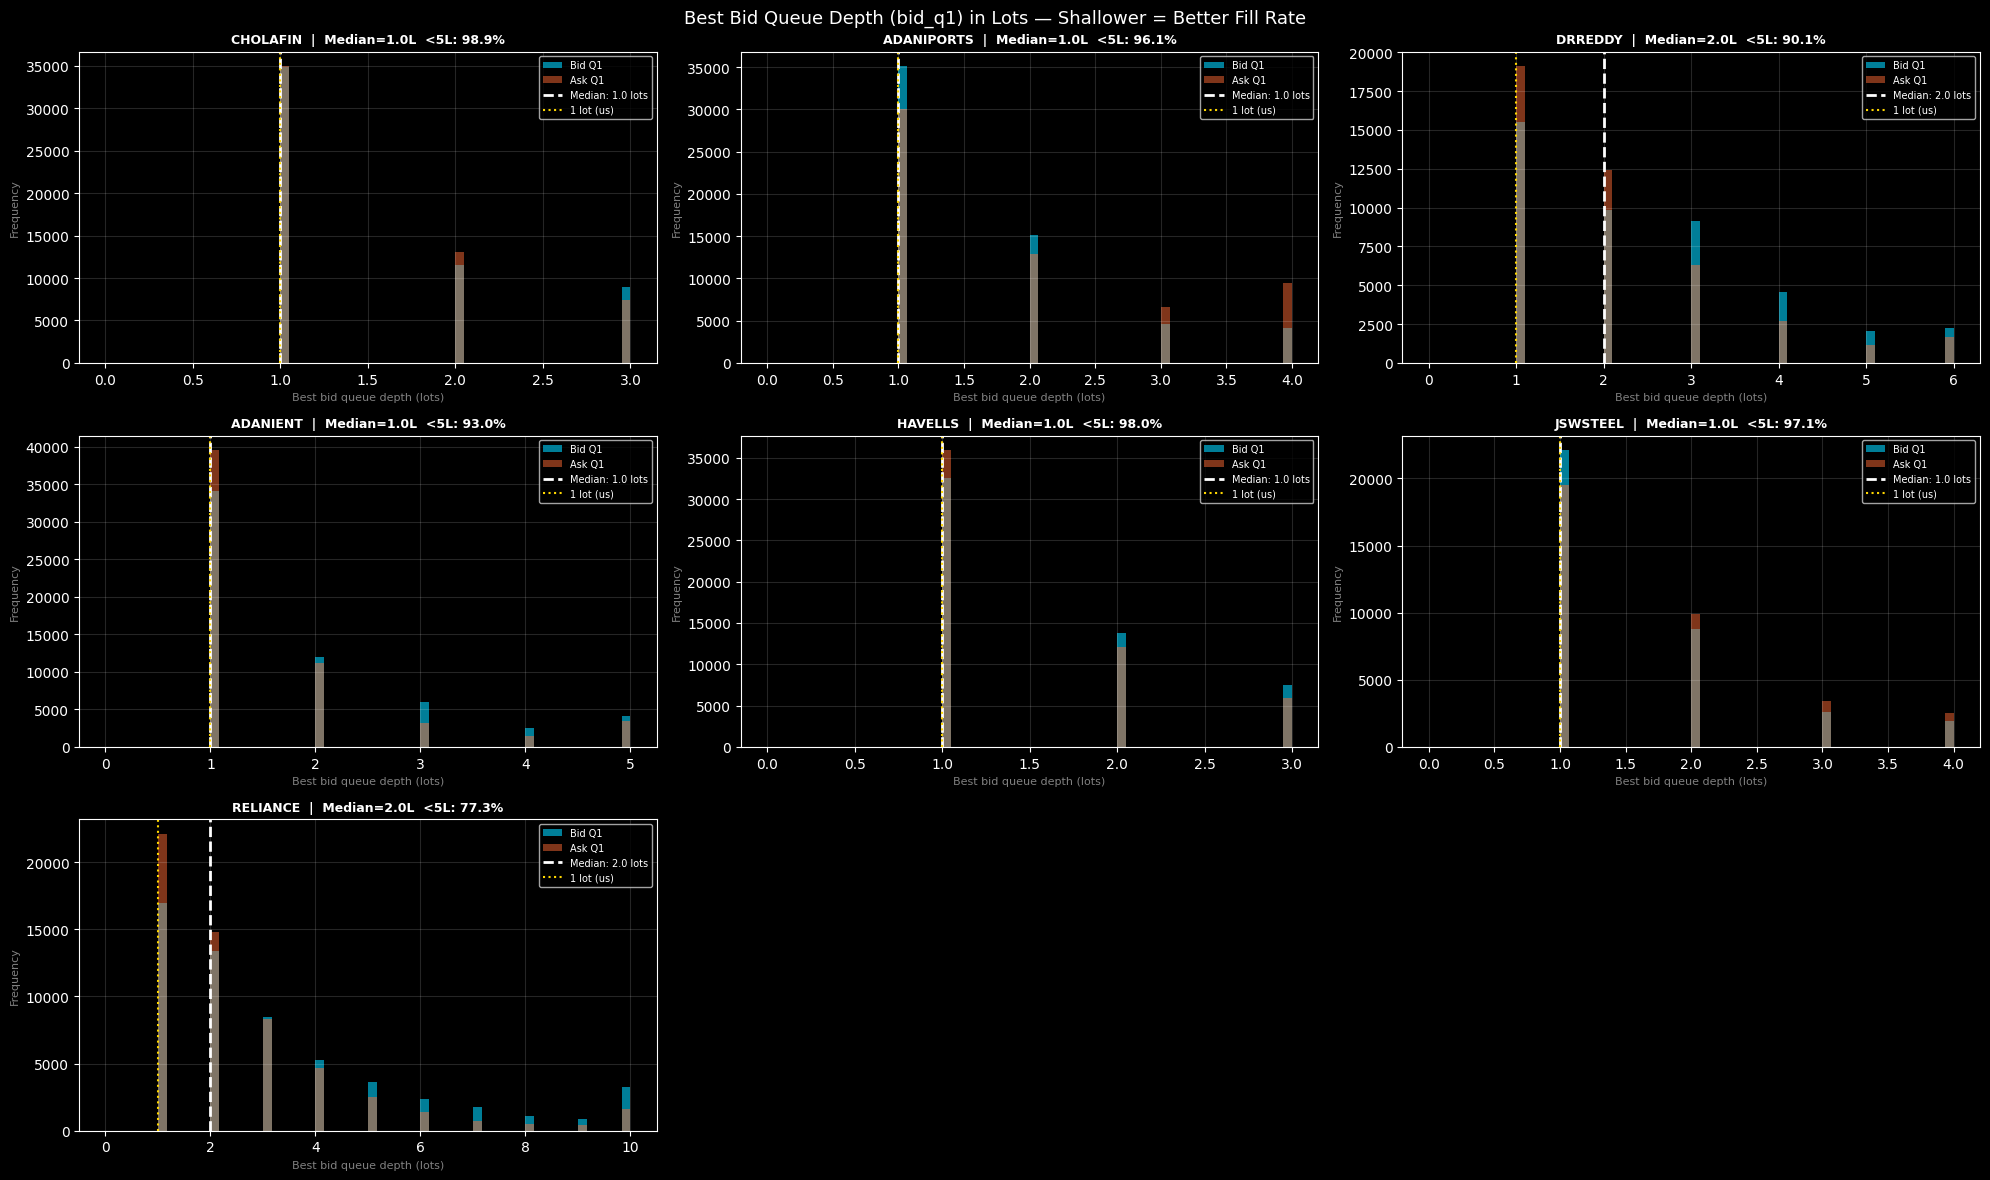


Symbol                          Median(L)    P25    P75    P90     <5L%    <10L%
--------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                      1.0    1.0    2.0    3.0    98.9%    99.8%
ADANIPORTS26MAYFUT                    1.0    1.0    2.0    3.0    96.1%    98.9%
DRREDDY26MAYFUT                       2.0    1.0    3.0    4.0    90.1%    98.8%
ADANIENT26MAYFUT                      1.0    1.0    2.0    4.0    93.0%    97.9%
HAVELLS26MAYFUT                       1.0    1.0    2.0    3.0    98.0%    99.5%
JSWSTEEL26MAYFUT                      1.0    1.0    2.0    3.0    97.1%    99.0%
RELIANCE26MAYFUT                      2.0    1.0    4.0    7.0    77.3%    94.3%


In [3]:
queue_stats = {}
n    = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, (sym, df) in enumerate(symbol_data.items()):
    lot  = LOT_SIZES.get(sym, 1)
    ax   = axes[i]
    name = sym.replace('26MAYFUT', '')

    bid_q1 = df['bid_q1'].dropna()
    ask_q1 = df['ask_q1'].dropna()

    # Convert to lots
    bid_lots = bid_q1 / lot
    ask_lots = ask_q1 / lot

    queue_stats[sym] = {
        'median_bid_q1_lots': round(float(bid_lots.median()), 1),
        'p25_bid_q1_lots':    round(float(bid_lots.quantile(0.25)), 1),
        'p75_bid_q1_lots':    round(float(bid_lots.quantile(0.75)), 1),
        'p90_bid_q1_lots':    round(float(bid_lots.quantile(0.90)), 1),
        'pct_shallow_lt5':    round(float((bid_lots < 5).mean() * 100), 1),
        'pct_shallow_lt10':   round(float((bid_lots < 10).mean() * 100), 1),
        'median_ask_q1_lots': round(float(ask_lots.median()), 1),
    }

    clip_p = bid_lots.quantile(0.95)
    ax.hist(bid_lots.clip(upper=clip_p), bins=60,
            color='#00d4ff', alpha=0.6, label='Bid Q1')
    ax.hist(ask_lots.clip(upper=clip_p), bins=60,
            color='#ff6b35', alpha=0.5, label='Ask Q1')
    ax.axvline(bid_lots.median(), color='white', lw=2, ls='--',
               label=f'Median: {bid_lots.median():.1f} lots')
    ax.axvline(1, color='#ffd700', lw=1.5, ls=':',
               label='1 lot (us)')
    ax.set_title(
        f"{name}  |  Median={bid_lots.median():.1f}L  "
        f"<5L: {queue_stats[sym]['pct_shallow_lt5']}%",
        color='white', fontsize=9, fontweight='bold'
    )
    ax.set_xlabel('Best bid queue depth (lots)', color='gray', fontsize=8)
    ax.set_ylabel('Frequency', color='gray', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Best Bid Queue Depth (bid_q1) in Lots — Shallower = Better Fill Rate',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/queue_depth_bid_q1.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

print(f"\n{'Symbol':30s} {'Median(L)':>10} {'P25':>6} {'P75':>6} {'P90':>6} {'<5L%':>8} {'<10L%':>8}")
print('-' * 80)
for sym, s in queue_stats.items():
    print(f"{sym:30s} {s['median_bid_q1_lots']:>10.1f} "
          f"{s['p25_bid_q1_lots']:>6.1f} {s['p75_bid_q1_lots']:>6.1f} "
          f"{s['p90_bid_q1_lots']:>6.1f} {s['pct_shallow_lt5']:>7.1f}% "
          f"{s['pct_shallow_lt10']:>7.1f}%")

## 3. Full Order Book Depth Profile (5 Levels)

How does liquidity thin out as we move away from best bid/ask?  
This tells us how much a large market order needs to eat through before reaching us.

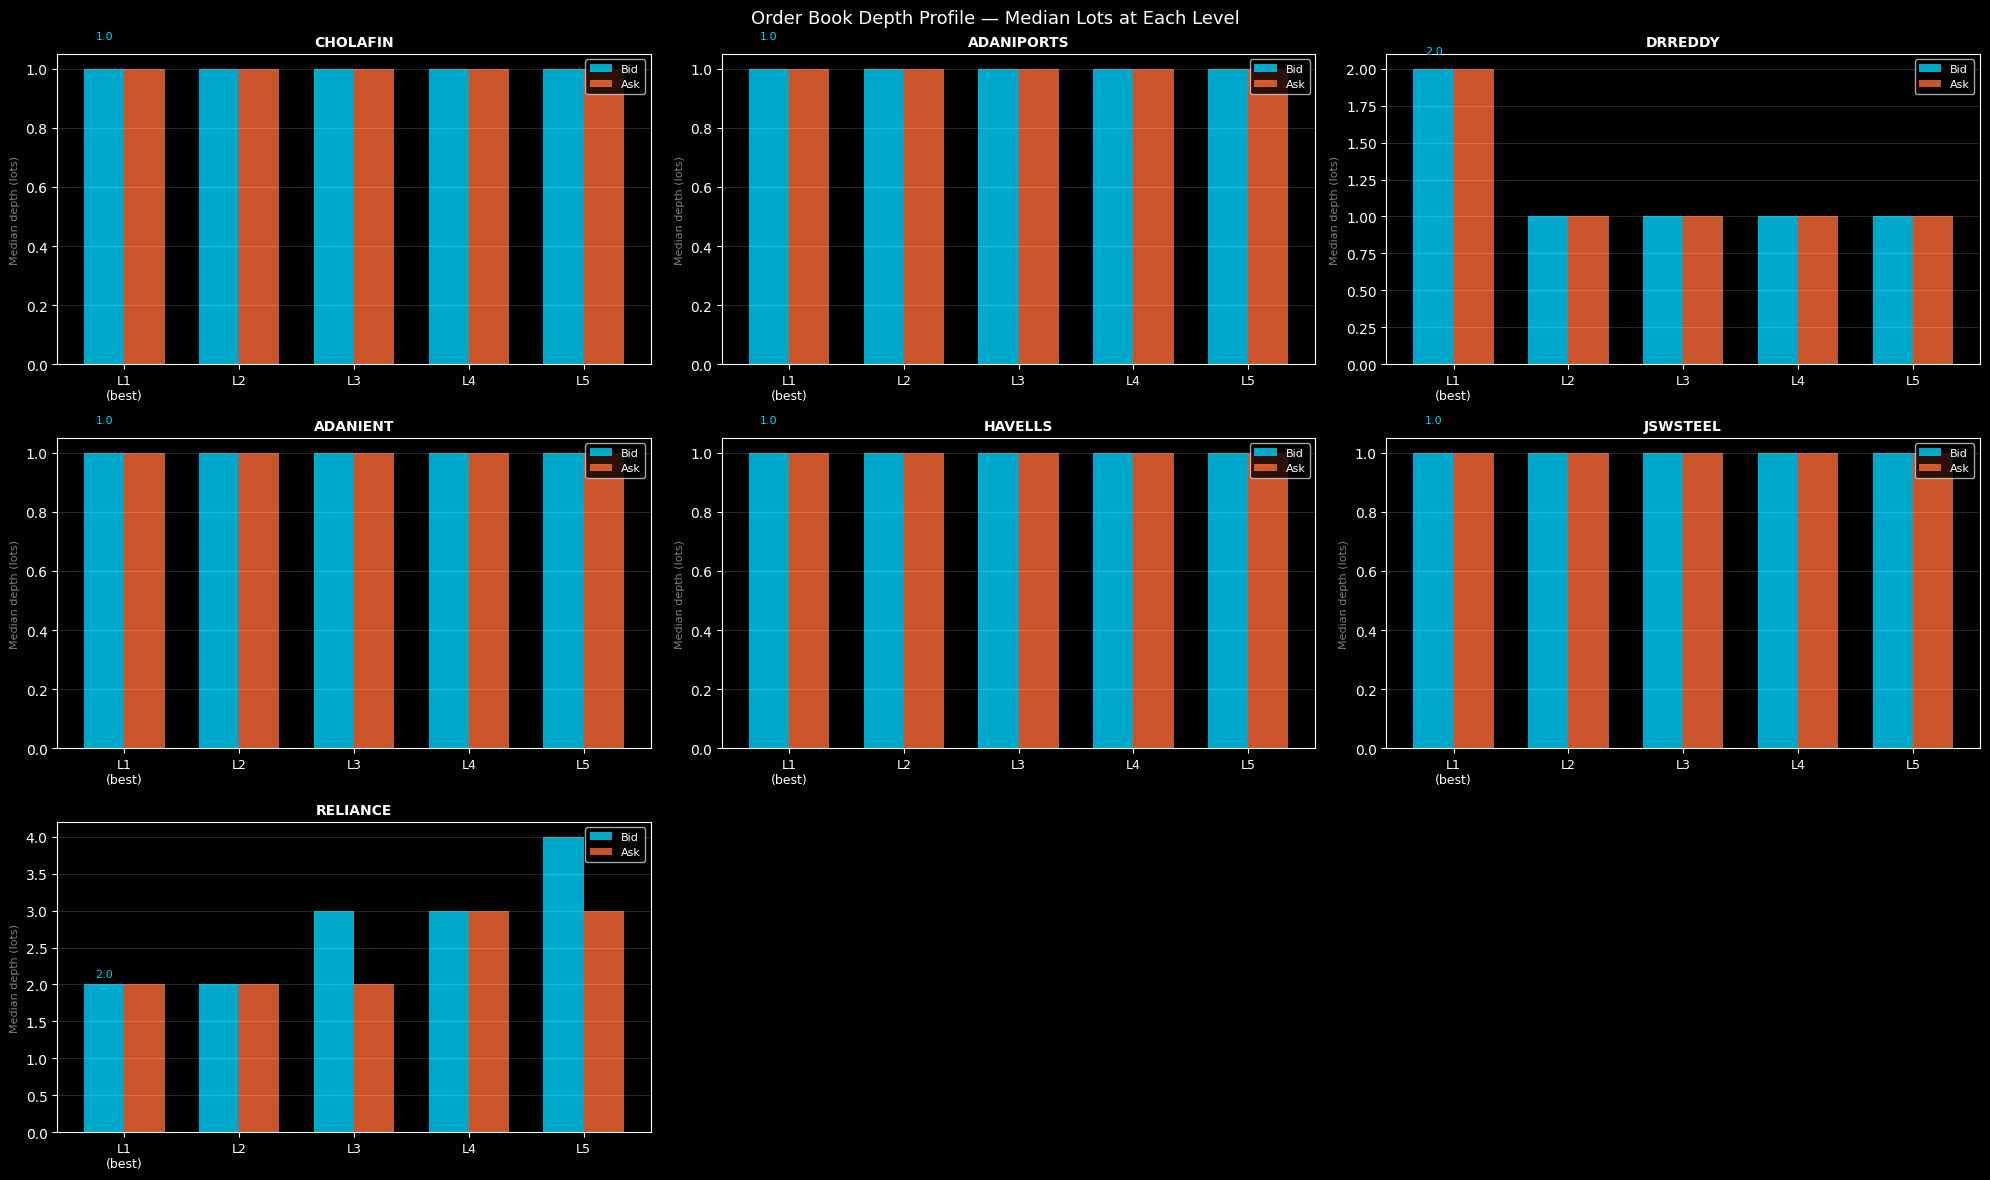

Saved: findings/book_depth_profile.png


In [4]:
n    = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

book_profiles = {}
for i, (sym, df) in enumerate(symbol_data.items()):
    lot  = LOT_SIZES.get(sym, 1)
    ax   = axes[i]
    name = sym.replace('26MAYFUT', '')

    # Median qty at each level
    bid_levels = [df[f'bid_q{l}'].median() / lot for l in range(1, 6)]
    ask_levels = [df[f'ask_q{l}'].median() / lot for l in range(1, 6)]

    book_profiles[sym] = {
        'bid_levels_median_lots': [round(x, 1) for x in bid_levels],
        'ask_levels_median_lots': [round(x, 1) for x in ask_levels],
    }

    levels = ['L1\n(best)', 'L2', 'L3', 'L4', 'L5']
    x      = np.arange(5)
    w      = 0.35

    ax.bar(x - w/2, bid_levels, w, color='#00d4ff', alpha=0.8, label='Bid')
    ax.bar(x + w/2, ask_levels, w, color='#ff6b35', alpha=0.8, label='Ask')
    ax.set_xticks(x)
    ax.set_xticklabels(levels, fontsize=9)
    ax.set_title(name, color='white', fontsize=10, fontweight='bold')
    ax.set_ylabel('Median depth (lots)', color='gray', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.15, axis='y')

    # Annotate L1
    ax.text(x[0] - w/2, bid_levels[0] + 0.1, f'{bid_levels[0]:.1f}',
            ha='center', fontsize=8, color='#00d4ff')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Order Book Depth Profile — Median Lots at Each Level',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/book_depth_profile.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: findings/book_depth_profile.png')

## 4. Queue Depth by Time-of-Day

Queue is shallowest during mid-day low-volume windows.  
That's when late-arriving orders (us, from GCP VM) get the best fill rates.

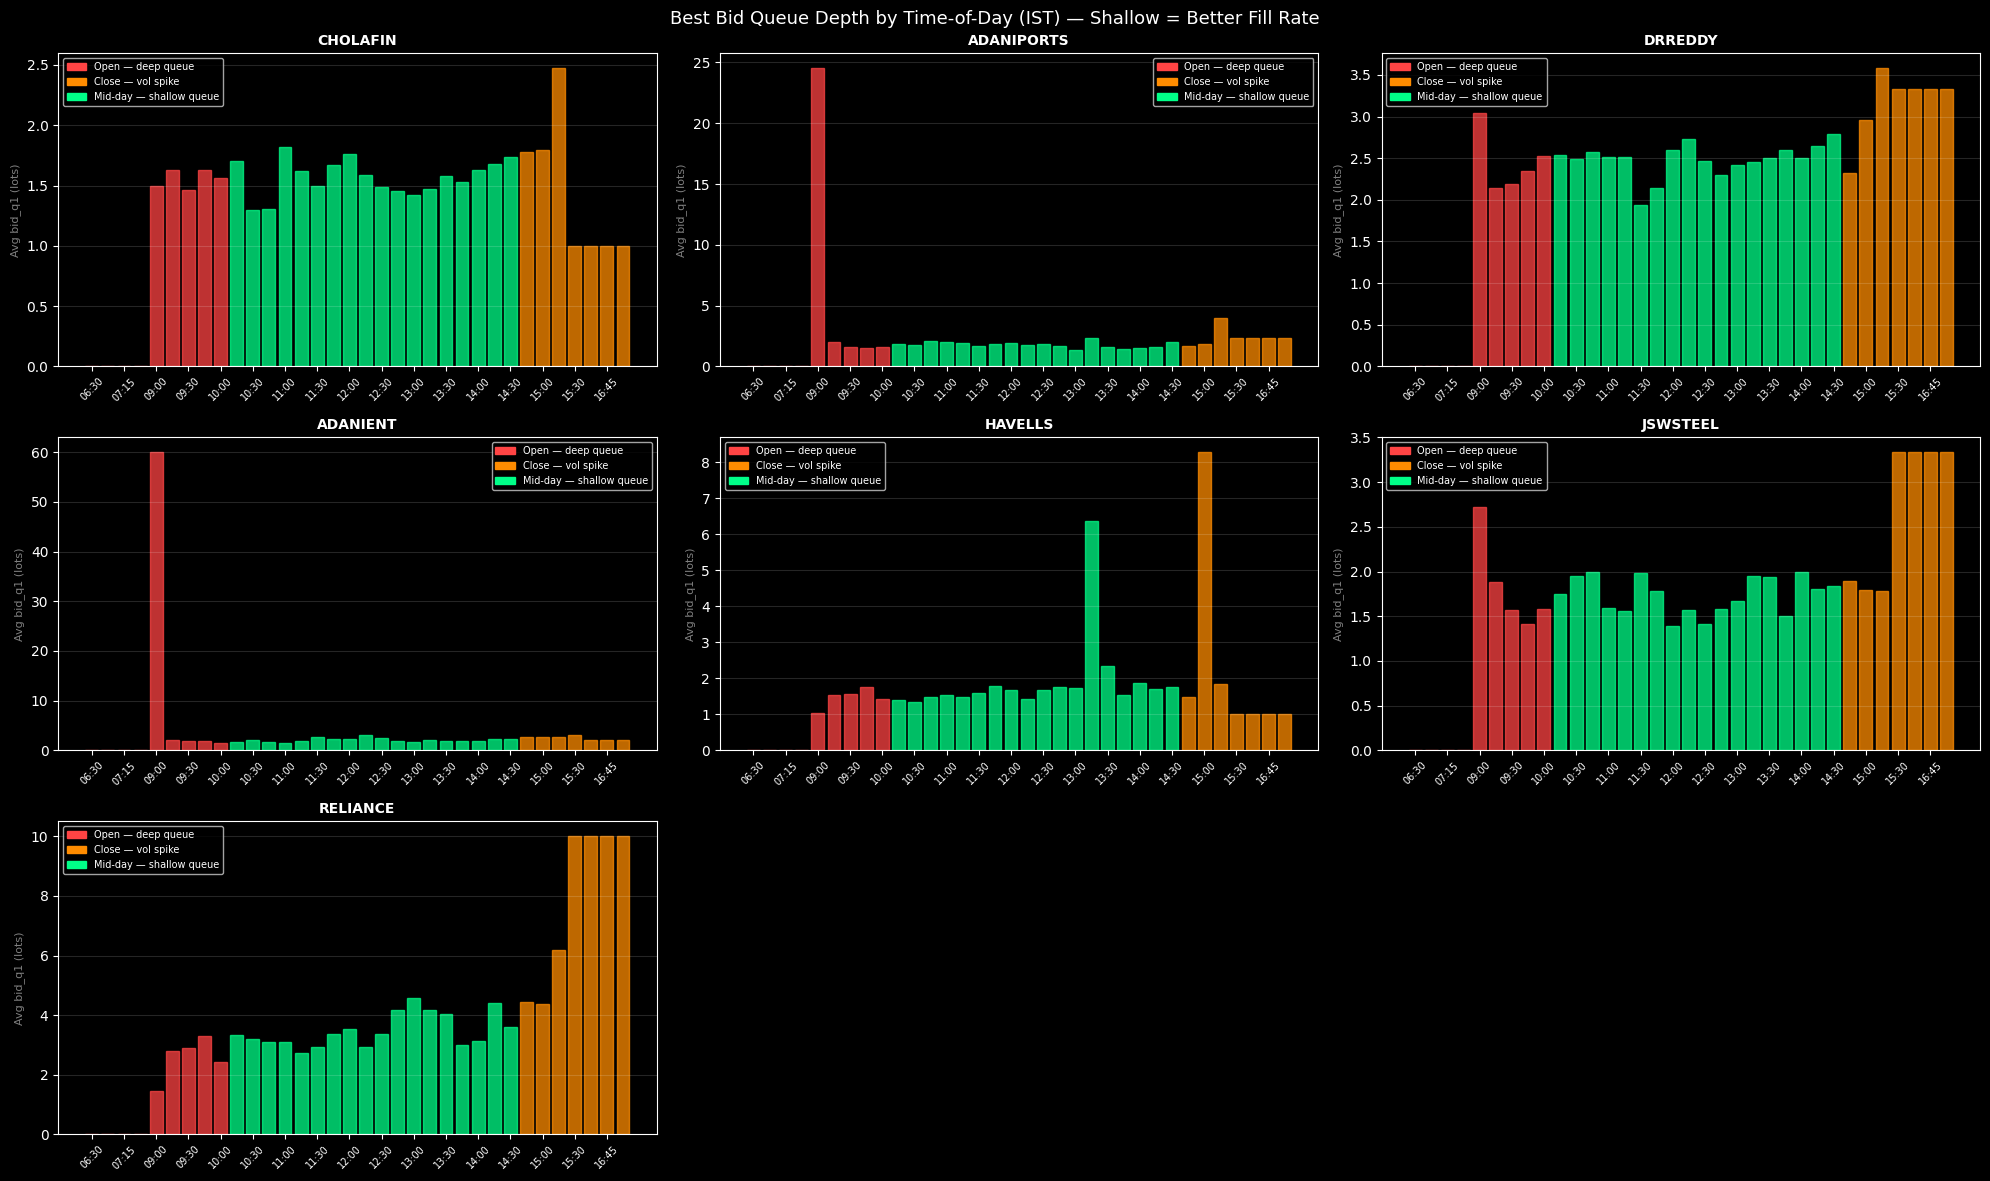

Saved: findings/queue_depth_tod.png


In [5]:
def queue_by_time(df: pd.DataFrame, bucket_min: int = 15) -> pd.DataFrame:
    df2 = df.copy()
    bucket_sec    = bucket_min * 60
    df2['bucket'] = (df2['ist_tod_sec'] // bucket_sec) * bucket_sec
    df2['hhmm']   = df2['bucket'].apply(
        lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}"
    )
    lot = 1  # will normalize per symbol outside
    grouped = df2.groupby(['date', 'hhmm']).agg(
        bid_q1_mean=('bid_q1', 'mean'),
        tick_count_sum=('tick_count', 'sum'),
        spread_mean_mean=('spread_mean', 'mean'),
    ).reset_index()
    return grouped.groupby('hhmm').mean(numeric_only=True).reset_index().sort_values('hhmm')


n    = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

tod_queue = {}
for i, (sym, df) in enumerate(symbol_data.items()):
    lot = LOT_SIZES.get(sym, 1)
    tod = queue_by_time(df)
    tod['bid_q1_lots'] = tod['bid_q1_mean'] / lot
    tod_queue[sym]     = tod

    ax   = axes[i]
    bars = ax.bar(range(len(tod)), tod['bid_q1_lots'],
                  color='#00d4ff', alpha=0.75, width=0.8)

    # Color windows: red=open (deep queue), green=mid-day (shallow)
    for bi, hhmm in enumerate(tod['hhmm']):
        if hhmm <= '10:00':
            bars[bi].set_color('#ff4444')
        elif hhmm >= '14:45':
            bars[bi].set_color('#ff8c00')
        elif '10:15' <= hhmm <= '14:30':
            bars[bi].set_color('#00ff88')

    ax.set_xticks(range(0, len(tod), 2))
    ax.set_xticklabels(tod['hhmm'].iloc[::2], rotation=45, fontsize=7)
    ax.set_title(sym.replace('26MAYFUT', ''), color='white', fontsize=10, fontweight='bold')
    ax.set_ylabel('Avg bid_q1 (lots)', color='gray', fontsize=8)
    ax.grid(alpha=0.15, axis='y')
    ax.legend(handles=[
        Patch(color='#ff4444', label='Open — deep queue'),
        Patch(color='#ff8c00', label='Close — vol spike'),
        Patch(color='#00ff88', label='Mid-day — shallow queue'),
    ], fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Best Bid Queue Depth by Time-of-Day (IST) — Shallow = Better Fill Rate',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/queue_depth_tod.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: findings/queue_depth_tod.png')

## 5. Tick Count by Time-of-Day

`tick_count` = number of price updates in each 1s bar.  
High tick count = active market = queue is being worked through fast.  
Low tick count = quiet market = queue builds up, fills are slow.

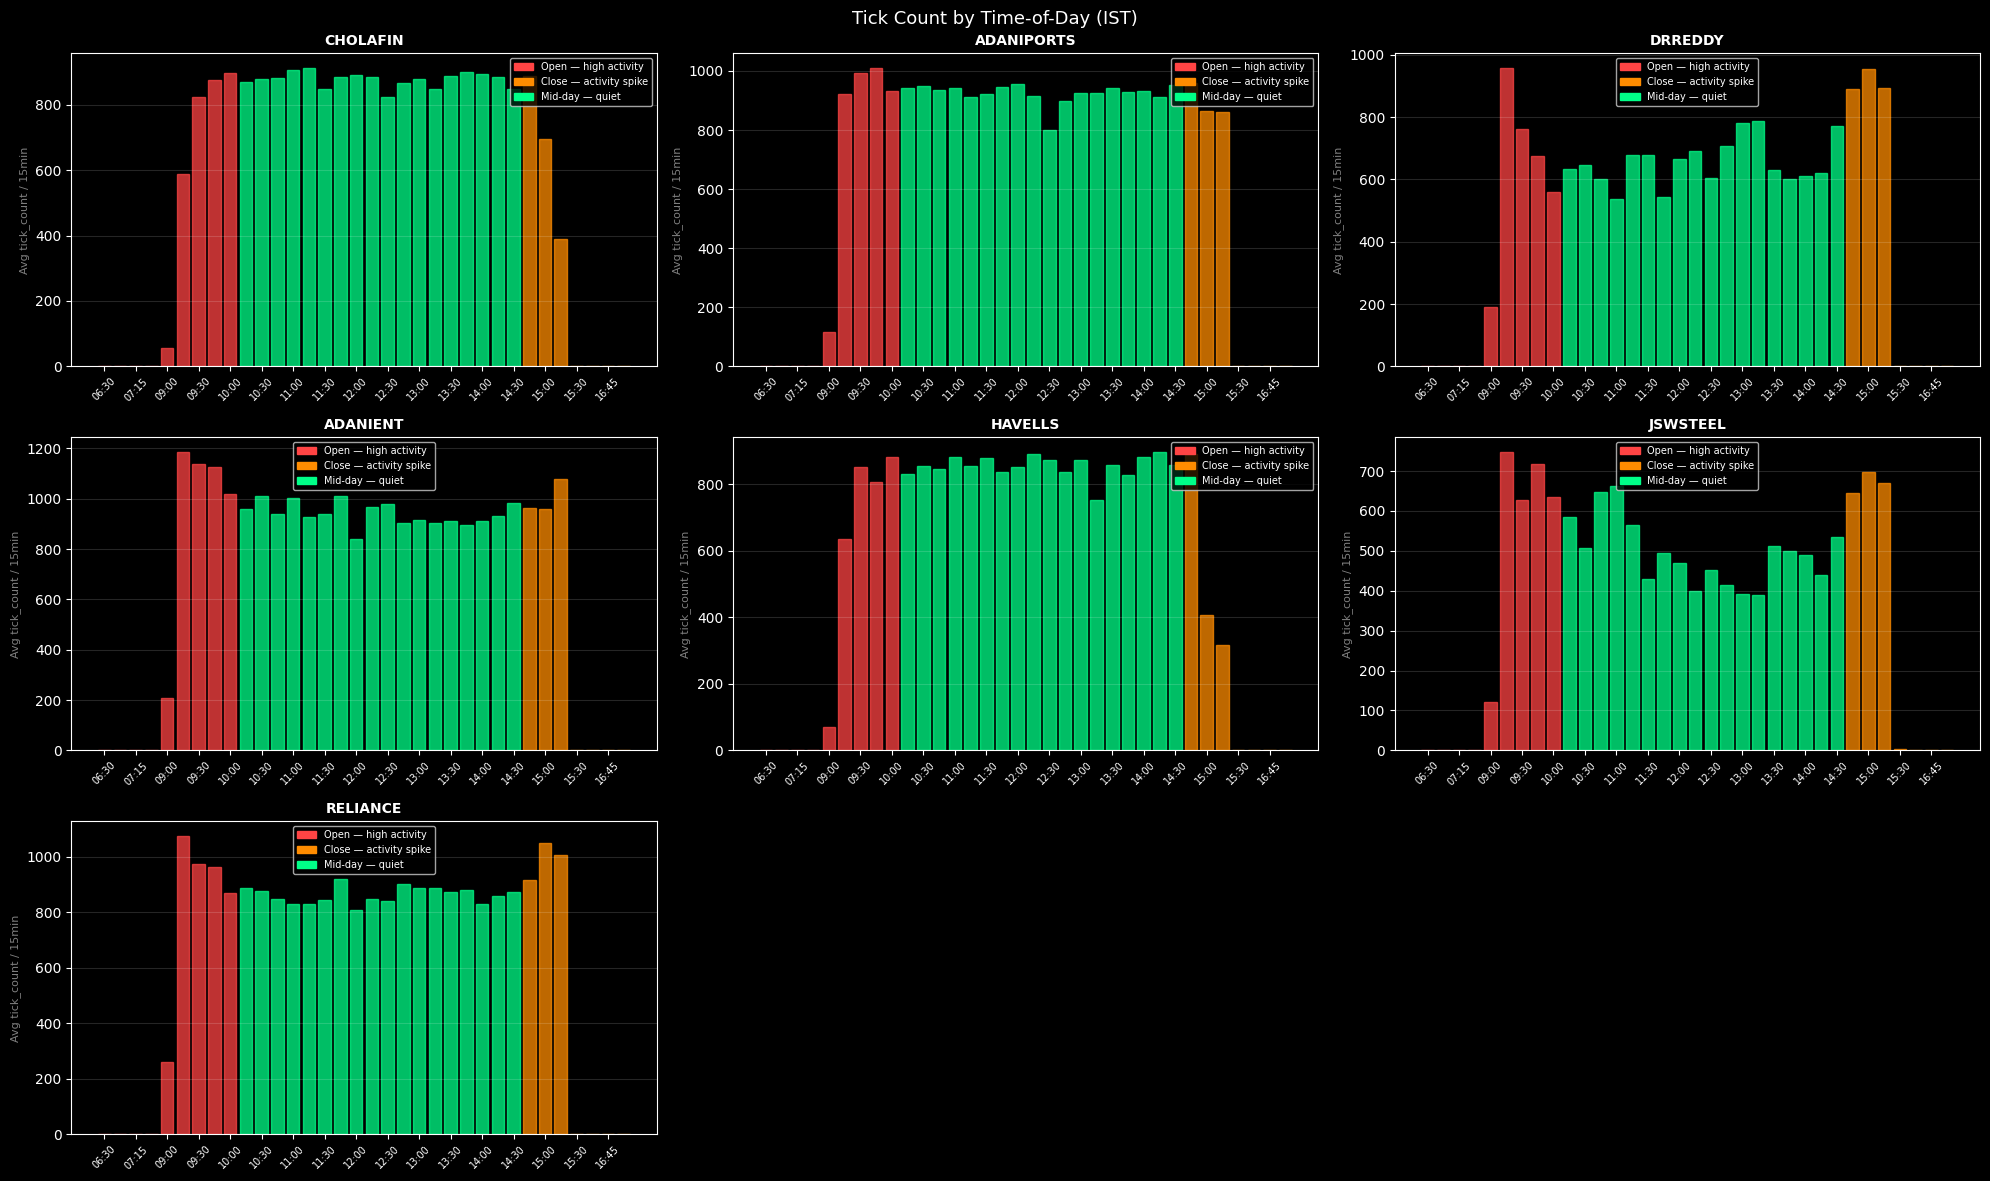

Saved: findings/tick_count_tod.png


In [6]:
def ticks_by_time(df: pd.DataFrame, bucket_min: int = 15) -> pd.DataFrame:
    df2 = df.copy()
    bucket_sec    = bucket_min * 60
    df2['bucket'] = (df2['ist_tod_sec'] // bucket_sec) * bucket_sec
    df2['hhmm']   = df2['bucket'].apply(
        lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}"
    )
    grouped = df2.groupby(['date', 'hhmm'])['tick_count'].sum().reset_index()
    return grouped.groupby('hhmm')['tick_count'].mean().reset_index().sort_values('hhmm')


n    = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, (sym, df) in enumerate(symbol_data.items()):
    tod  = ticks_by_time(df)
    ax   = axes[i]
    bars = ax.bar(range(len(tod)), tod['tick_count'],
                  color='#00d4ff', alpha=0.75, width=0.8)

    for bi, hhmm in enumerate(tod['hhmm']):
        if hhmm <= '10:00':
            bars[bi].set_color('#ff4444')
        elif hhmm >= '14:45':
            bars[bi].set_color('#ff8c00')
        elif '10:15' <= hhmm <= '14:30':
            bars[bi].set_color('#00ff88')

    ax.set_xticks(range(0, len(tod), 2))
    ax.set_xticklabels(tod['hhmm'].iloc[::2], rotation=45, fontsize=7)
    ax.set_title(sym.replace('26MAYFUT', ''), color='white', fontsize=10, fontweight='bold')
    ax.set_ylabel('Avg tick_count / 15min', color='gray', fontsize=8)
    ax.grid(alpha=0.15, axis='y')
    ax.legend(handles=[
        Patch(color='#ff4444', label='Open — high activity'),
        Patch(color='#ff8c00', label='Close — activity spike'),
        Patch(color='#00ff88', label='Mid-day — quiet'),
    ], fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Tick Count by Time-of-Day (IST)',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/tick_count_tod.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: findings/tick_count_tod.png')

## 6. Order Flow Imbalance — Does It Predict Direction?

You have multiple imbalance signals:
- `imbalance_last` — most recent imbalance snapshot
- `imbalance_ma_10s/30s/60s` — smoothed versions
- `volume_delta` — cumulative buy minus sell volume

**Hit rate > 55%** = useful for quote skewing (quote more aggressively on the about-to-be-hit side).

In [7]:
def imbalance_analysis(df: pd.DataFrame, forward_bars: int = 3) -> dict:
    df2 = df.copy().sort_values('ts_sec').reset_index(drop=True)

    results = {}
    for signal_col in ['imbalance_last', 'imbalance_ma_10s', 'imbalance_ma_30s',
                        'imbalance_ma_60s', 'volume_delta']:
        if signal_col not in df2.columns:
            continue

        # Forward return
        df2['fwd_ret'] = df2['close'].shift(-forward_bars) / df2['close'] - 1

        sig = df2[signal_col]
        # Normalize volume_delta to -1/+1 range
        if signal_col == 'volume_delta':
            p95 = sig.abs().quantile(0.95)
            sig = sig / p95.clip(1)

        df2['signal'] = 0
        df2.loc[sig >  0.2, 'signal'] =  1
        df2.loc[sig < -0.2, 'signal'] = -1

        active = df2[df2['signal'] != 0].dropna(subset=['fwd_ret'])
        if len(active) < 50:
            continue

        correct  = ((active['signal'] == 1) & (active['fwd_ret'] > 0)) | \
                   ((active['signal'] == -1) & (active['fwd_ret'] < 0))
        hit_rate = float(correct.mean() * 100)
        corr     = float(df2[signal_col].corr(df2['fwd_ret']))

        results[signal_col] = {
            'hit_rate_pct':  round(hit_rate, 2),
            'corr':          round(corr, 4),
            'n_signal_bars': len(active),
            'pct_active':    round(float((df2['signal'] != 0).mean() * 100), 1),
        }

    return results


imb_results = {}
for sym, df in symbol_data.items():
    imb_results[sym] = imbalance_analysis(df, forward_bars=3)

# Print summary table
print(f"{'Symbol':25s} {'Signal':20s} {'Hit Rate':>10} {'Corr':>8} {'Active%':>9}")
print('-' * 78)
for sym, results in imb_results.items():
    for sig_col, r in results.items():
        flag = ' ← USE' if r['hit_rate_pct'] > 55 else ''
        print(f"{sym.replace('26MAYFUT',''):25s} {sig_col:20s} "
              f"{r['hit_rate_pct']:>9.1f}% {r['corr']:>8.4f} "
              f"{r['pct_active']:>8.1f}%{flag}")
    print()

Symbol                    Signal                 Hit Rate     Corr   Active%
------------------------------------------------------------------------------
CHOLAFIN                  imbalance_last            22.7%   0.0383      0.2%
CHOLAFIN                  imbalance_ma_10s          21.4%   0.0450      0.3%
CHOLAFIN                  imbalance_ma_30s          18.3%   0.0034      0.4%
CHOLAFIN                  imbalance_ma_60s          22.5%  -0.0040      0.6%
CHOLAFIN                  volume_delta              16.7%  -0.0009      1.8%

ADANIPORTS                imbalance_last            16.4%   0.0350      0.2%
ADANIPORTS                imbalance_ma_10s          18.5%   0.0408      0.3%
ADANIPORTS                imbalance_ma_30s          22.6%   0.0231      0.4%
ADANIPORTS                imbalance_ma_60s          28.7%   0.0232      0.5%
ADANIPORTS                volume_delta              24.4%  -0.0018      4.6%

DRREDDY                   imbalance_last            36.9%   0.0266      

## 7. Visualize Imbalance Distributions

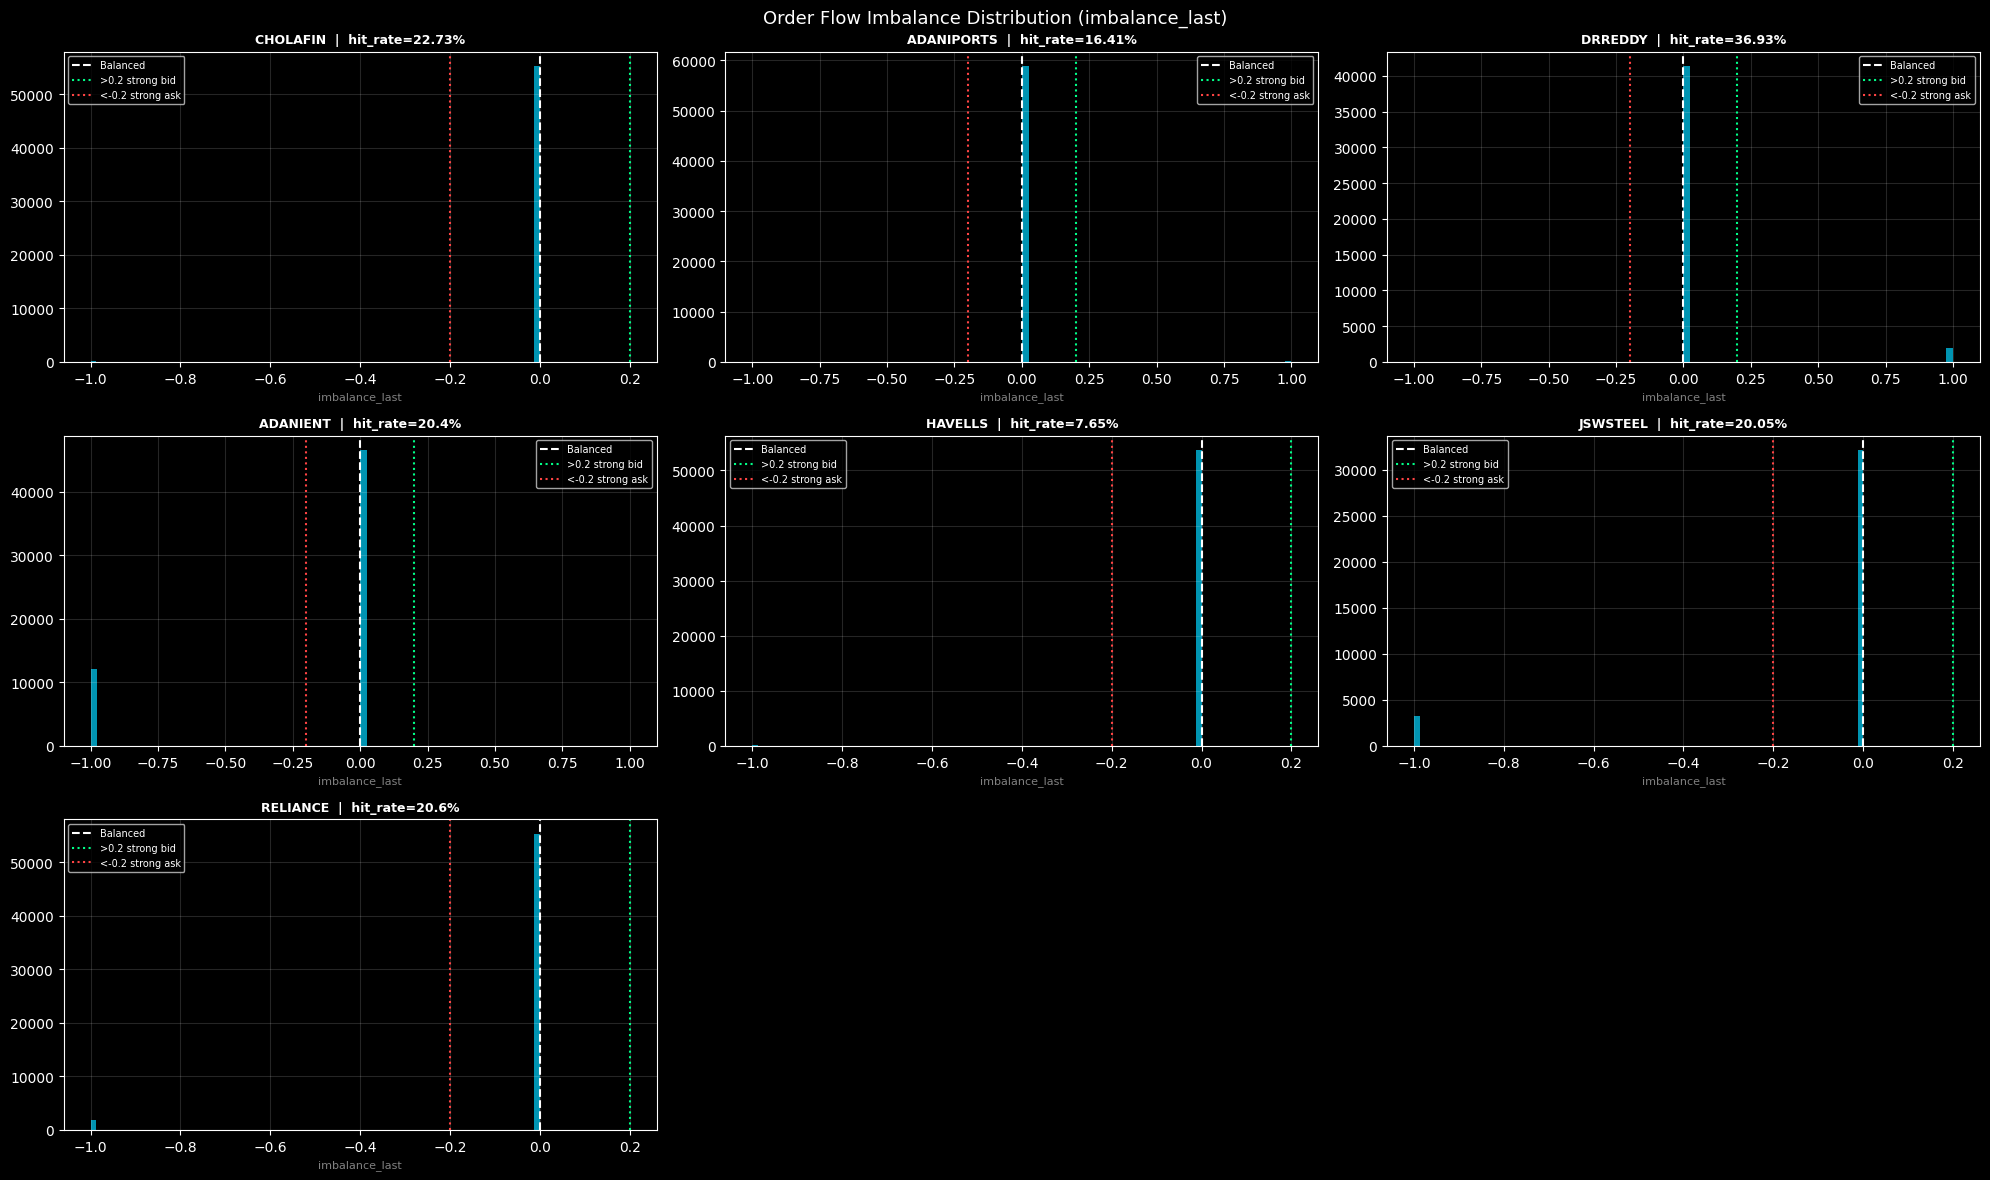

Saved: findings/imbalance_dist.png


In [8]:
n    = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, (sym, df) in enumerate(symbol_data.items()):
    ax   = axes[i]
    name = sym.replace('26MAYFUT', '')
    imb  = df['imbalance_last'].dropna()

    ax.hist(imb, bins=80, color='#00d4ff', alpha=0.7, edgecolor='none')
    ax.axvline(0,    color='white',   lw=1.5, ls='--', label='Balanced')
    ax.axvline( 0.2, color='#00ff88', lw=1.5, ls=':', label='>0.2 strong bid')
    ax.axvline(-0.2, color='#ff4444', lw=1.5, ls=':', label='<-0.2 strong ask')

    res = imb_results[sym].get('imbalance_last', {})
    hr  = res.get('hit_rate_pct', 'N/A')
    ax.set_title(f"{name}  |  hit_rate={hr}%",
                 color='white', fontsize=9, fontweight='bold')
    ax.set_xlabel('imbalance_last', color='gray', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Order Flow Imbalance Distribution (imbalance_last)',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/imbalance_dist.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: findings/imbalance_dist.png')

## 8. Spread Width Analysis

When spread > 1 tick, queue competition drops dramatically — everyone at 1-tick has left.  
These wider-spread moments are our best fill opportunities.

We also have `spread_zscore` which tells us if spread is unusually wide right now.

In [9]:
tick_analysis = {}

print(f"{'Symbol':30s} {'Tick':>6} {'Spread=1T':>11} {'Spread=2T':>11} "
      f"{'Spread≥3T':>11} {'Tick bps':>10}")
print('-' * 82)

for sym, df in symbol_data.items():
    sp  = df['spread_mean'].dropna()
    sp  = sp[sp > 0]
    mid = df['close'].median()

    tick     = float(sp.mode().iloc[0]) if len(sp) > 0 else 1.0
    pct_1t   = float((sp <= tick * 1.1).mean() * 100)
    pct_2t   = float(((sp > tick * 1.1) & (sp <= tick * 2.1)).mean() * 100)
    pct_3t   = float((sp > tick * 2.1).mean() * 100)
    tick_bps = tick / mid * 10000 if mid > 0 else 0

    tick_analysis[sym] = {
        'tick_size':      round(tick, 4),
        'tick_bps':       round(tick_bps, 2),
        'pct_1tick':      round(pct_1t, 1),
        'pct_2tick':      round(pct_2t, 1),
        'pct_3tick_plus': round(pct_3t, 1),
        'mid_price':      round(float(mid), 2),
    }
    print(f"{sym:30s} {tick:>6.2f} {pct_1t:>10.1f}% {pct_2t:>10.1f}% "
          f"{pct_3t:>10.1f}% {tick_bps:>9.1f}")

print()
print('Interpretation: higher pct_2tick/3tick = more opportunities with thin queue')

Symbol                           Tick   Spread=1T   Spread=2T   Spread≥3T   Tick bps
----------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                 1.00       75.0%       24.4%        0.6%       6.4
ADANIPORTS26MAYFUT               1.00       69.3%       30.1%        0.6%       5.6
DRREDDY26MAYFUT                  1.00       94.1%        5.4%        0.5%       7.8
ADANIENT26MAYFUT                 2.00       68.3%       31.3%        0.4%       7.5
HAVELLS26MAYFUT                  1.00       73.9%       25.6%        0.4%       8.3
JSWSTEEL26MAYFUT                 1.00       86.1%       13.7%        0.3%       7.7
RELIANCE26MAYFUT                 1.00       99.5%        0.2%        0.3%       7.3

Interpretation: higher pct_2tick/3tick = more opportunities with thin queue


## 9. Volume Clustering — Burst vs Quiet Periods

In [10]:
def analyze_clustering(df: pd.DataFrame) -> dict:
    tc   = df['tick_count'].fillna(0)
    p25  = tc.quantile(0.25)
    p75  = tc.quantile(0.75)

    is_burst = (tc > p75).astype(int)
    is_quiet = (tc < p25).astype(int)

    def run_lengths(series):
        lengths, count, in_run = [], 0, False
        for v in series:
            if v == 1:
                count += 1
                in_run = True
            else:
                if in_run:
                    lengths.append(count)
                    count, in_run = 0, False
        return np.array(lengths)

    burst_runs = run_lengths(is_burst)
    quiet_runs = run_lengths(is_quiet)

    return {
        'pct_burst_bars':      round(float(is_burst.mean() * 100), 1),
        'pct_quiet_bars':      round(float(is_quiet.mean() * 100), 1),
        'median_burst_sec':    round(float(np.median(burst_runs)), 1) if len(burst_runs) else None,
        'median_quiet_sec':    round(float(np.median(quiet_runs)), 1) if len(quiet_runs) else None,
        'p75_burst_sec':       round(float(np.percentile(burst_runs, 75)), 1) if len(burst_runs) else None,
        'p75_quiet_sec':       round(float(np.percentile(quiet_runs, 75)), 1) if len(quiet_runs) else None,
        'burst_threshold_ticks': round(float(p75), 1),
        'quiet_threshold_ticks': round(float(p25), 1),
    }


cluster_results = {}
print(f"{'Symbol':30s} {'Burst%':>8} {'Quiet%':>8} {'Med burst':>11} {'Med quiet':>11} {'P75 quiet':>11}")
print('-' * 84)
for sym, df in symbol_data.items():
    res = analyze_clustering(df)
    cluster_results[sym] = res
    print(f"{sym:30s} {res['pct_burst_bars']:>7.1f}% {res['pct_quiet_bars']:>7.1f}% "
          f"{str(res['median_burst_sec']):>11} {str(res['median_quiet_sec']):>11} "
          f"{str(res['p75_quiet_sec']):>11}")

print()
print('Tip: if P75 quiet > 10s, there is time to cancel+rejoin queue at front during quiet periods.')

Symbol                           Burst%   Quiet%   Med burst   Med quiet   P75 quiet
------------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                  13.1%     0.0%         1.0        None        None
ADANIPORTS26MAYFUT                17.4%     0.0%         1.0        None        None
DRREDDY26MAYFUT                   20.8%     0.0%         1.0        None        None
ADANIENT26MAYFUT                  23.8%     0.0%         1.0        None        None
HAVELLS26MAYFUT                   12.3%     0.0%         1.0        None        None
JSWSTEEL26MAYFUT                  15.6%     0.0%         1.0        None        None
RELIANCE26MAYFUT                  17.8%     0.0%         1.0        None        None

Tip: if P75 quiet > 10s, there is time to cancel+rejoin queue at front during quiet periods.


## 10. Fill Score by Time Window

Combined score using:
- Low bid_q1 (shallow queue) → higher fill probability
- Low tick_count (quiet) → less competition
- Wide spread → less queue competition

Normalized 0-100. Green windows = best times to actively quote.

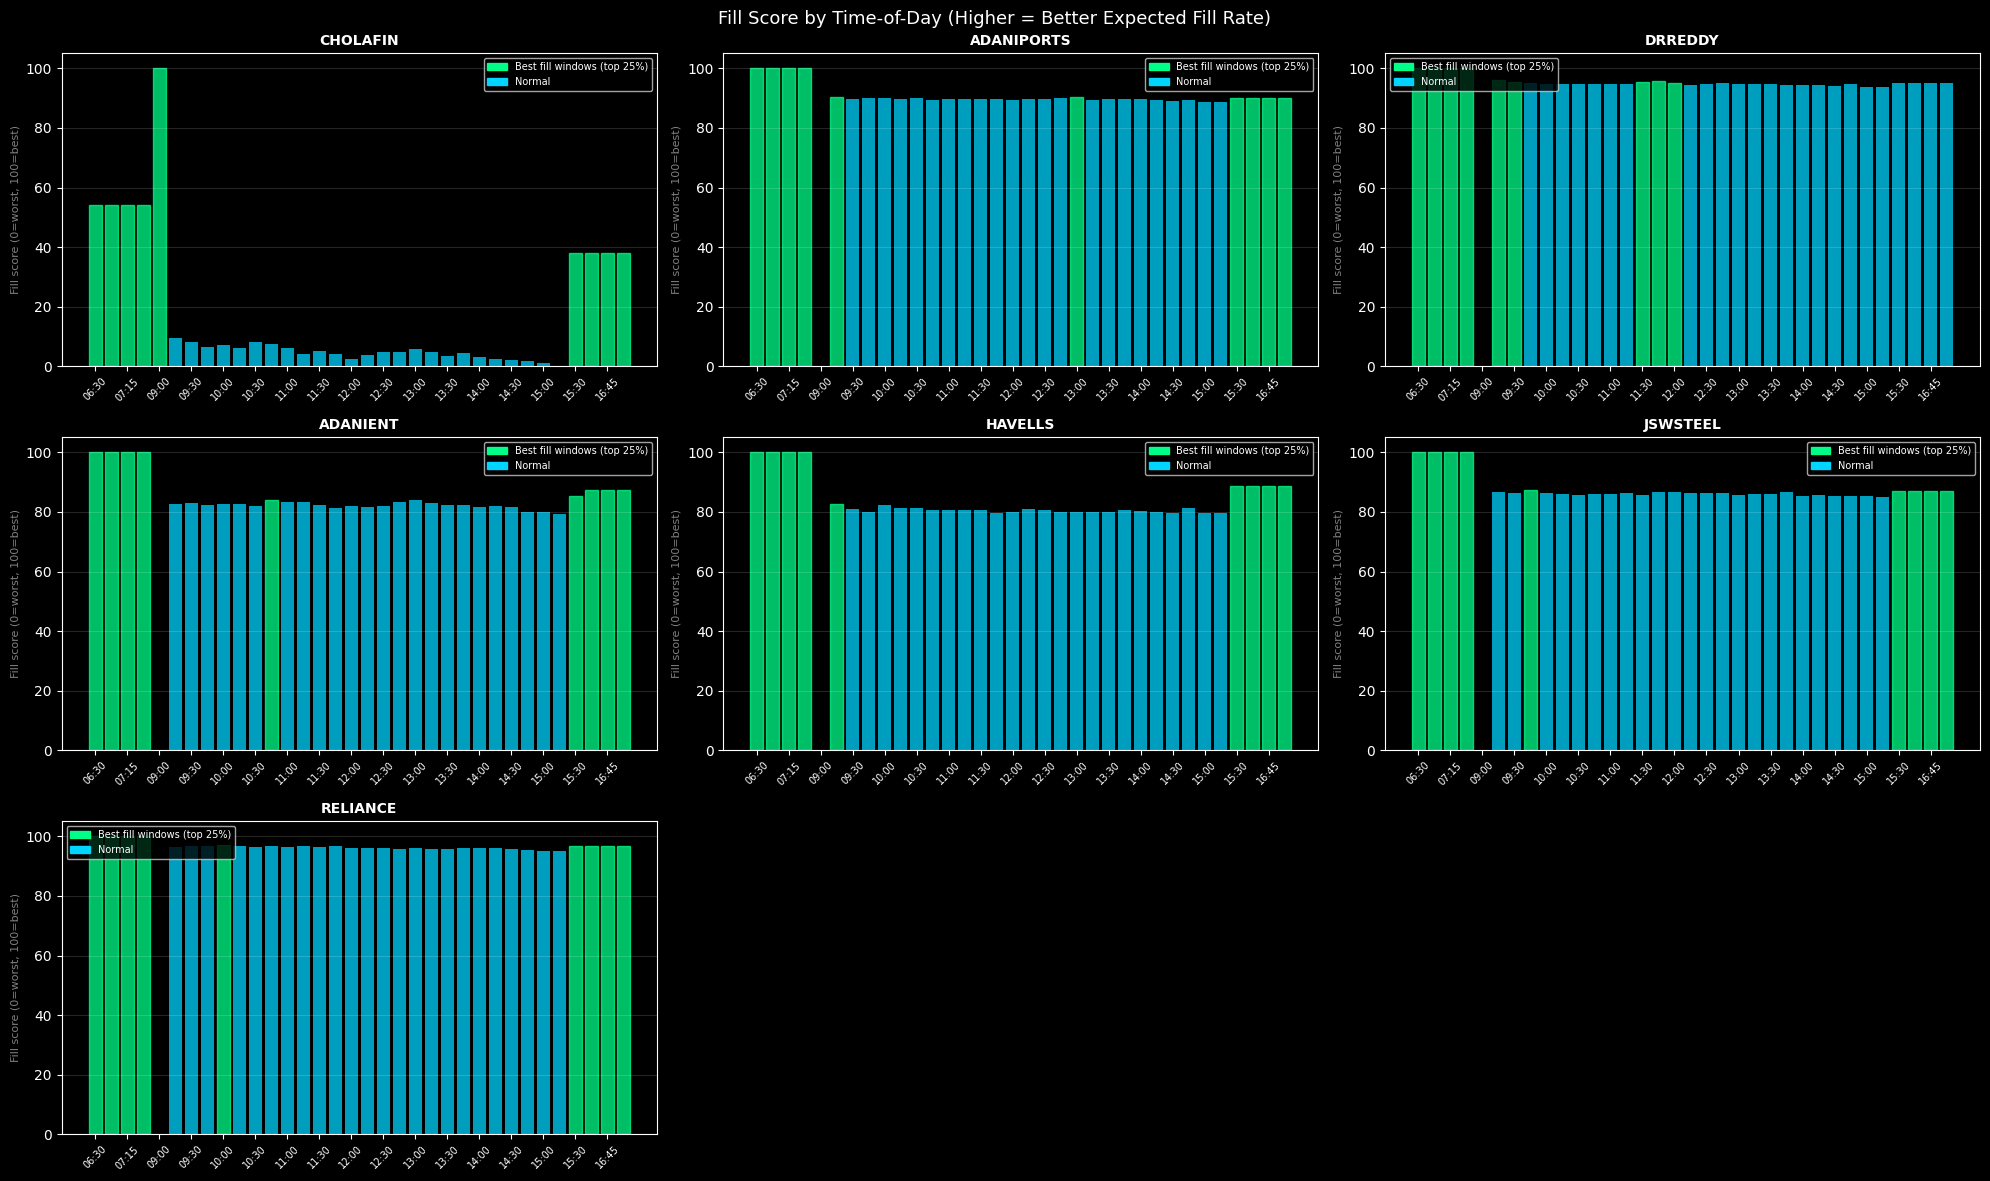


Best fill windows per symbol:
  CHOLAFIN26MAYFUT               ['06:30', '07:00', '07:15', '08:00', '09:00', '15:30', '16:15', '16:45', '17:00']
  ADANIPORTS26MAYFUT             ['06:30', '07:00', '07:15', '08:00', '09:15', '13:00', '15:30', '16:15', '16:45', '17:00']
  DRREDDY26MAYFUT                ['06:30', '07:00', '07:15', '08:00', '09:15', '09:30', '11:30', '11:45', '12:00']
  ADANIENT26MAYFUT               ['06:30', '07:00', '07:15', '08:00', '10:45', '15:30', '16:15', '16:45', '17:00']
  HAVELLS26MAYFUT                ['06:30', '07:00', '07:15', '08:00', '09:15', '15:30', '16:15', '16:45', '17:00']
  JSWSTEEL26MAYFUT               ['06:30', '07:00', '07:15', '08:00', '09:45', '15:30', '16:15', '16:45', '17:00']
  RELIANCE26MAYFUT               ['06:30', '07:00', '07:15', '08:00', '10:00', '15:30', '16:15', '16:45', '17:00']


In [11]:
n    = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

fill_windows = {}
for i, (sym, df) in enumerate(symbol_data.items()):
    lot = LOT_SIZES.get(sym, 1)
    df2 = df.copy()

    bucket_sec    = 15 * 60
    df2['bucket'] = (df2['ist_tod_sec'] // bucket_sec) * bucket_sec
    df2['hhmm']   = df2['bucket'].apply(
        lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}"
    )

    # Normalize components (lower = better for fill rate)
    df2['q1_norm']     = df2['bid_q1'] / (df2['bid_q1'].quantile(0.95) + 1)
    df2['tick_norm']   = df2['tick_count'] / (df2['tick_count'].quantile(0.95) + 1)
    df2['spread_norm'] = df2['spread_mean'] / (df2['spread_mean'].quantile(0.95) + 0.01)

    # Fill score: low queue + low ticks + wide spread = better
    df2['fill_score'] = (1 / (df2['q1_norm'] + 0.1)) * \
                        (1 / (df2['tick_norm'] + 0.1)) * \
                        (1 + df2['spread_norm'])

    grouped   = df2.groupby(['date', 'hhmm'])['fill_score'].mean().reset_index()
    tod_score = grouped.groupby('hhmm')['fill_score'].mean().reset_index().sort_values('hhmm')

    # Normalize 0-100
    rng = tod_score['fill_score'].max() - tod_score['fill_score'].min()
    tod_score['score_norm'] = (
        (tod_score['fill_score'] - tod_score['fill_score'].min()) / rng * 100
        if rng > 0 else 50
    )

    top_q = tod_score['score_norm'].quantile(0.75)
    best_windows = tod_score[tod_score['score_norm'] >= top_q]['hhmm'].tolist()
    fill_windows[sym] = best_windows

    ax   = axes[i]
    bars = ax.bar(range(len(tod_score)), tod_score['score_norm'],
                  color='#00d4ff', alpha=0.75, width=0.8)

    for bi, score in enumerate(tod_score['score_norm']):
        if score >= top_q:
            bars[bi].set_color('#00ff88')

    ax.set_xticks(range(0, len(tod_score), 2))
    ax.set_xticklabels(tod_score['hhmm'].iloc[::2], rotation=45, fontsize=7)
    ax.set_title(sym.replace('26MAYFUT', ''), color='white', fontsize=10, fontweight='bold')
    ax.set_ylabel('Fill score (0=worst, 100=best)', color='gray', fontsize=8)
    ax.grid(alpha=0.15, axis='y')
    ax.legend(handles=[
        Patch(color='#00ff88', label='Best fill windows (top 25%)'),
        Patch(color='#00d4ff', label='Normal'),
    ], fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Fill Score by Time-of-Day (Higher = Better Expected Fill Rate)',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/fill_score_tod.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

print('\nBest fill windows per symbol:')
for sym, windows in fill_windows.items():
    print(f"  {sym:30s} {windows}")

## 11. Price Impact Analysis

You have a `price_impact` column — this directly measures how much price moves per unit of order flow.  
High price impact = informed flow = dangerous for MM (this is Kyle's Lambda in disguise).

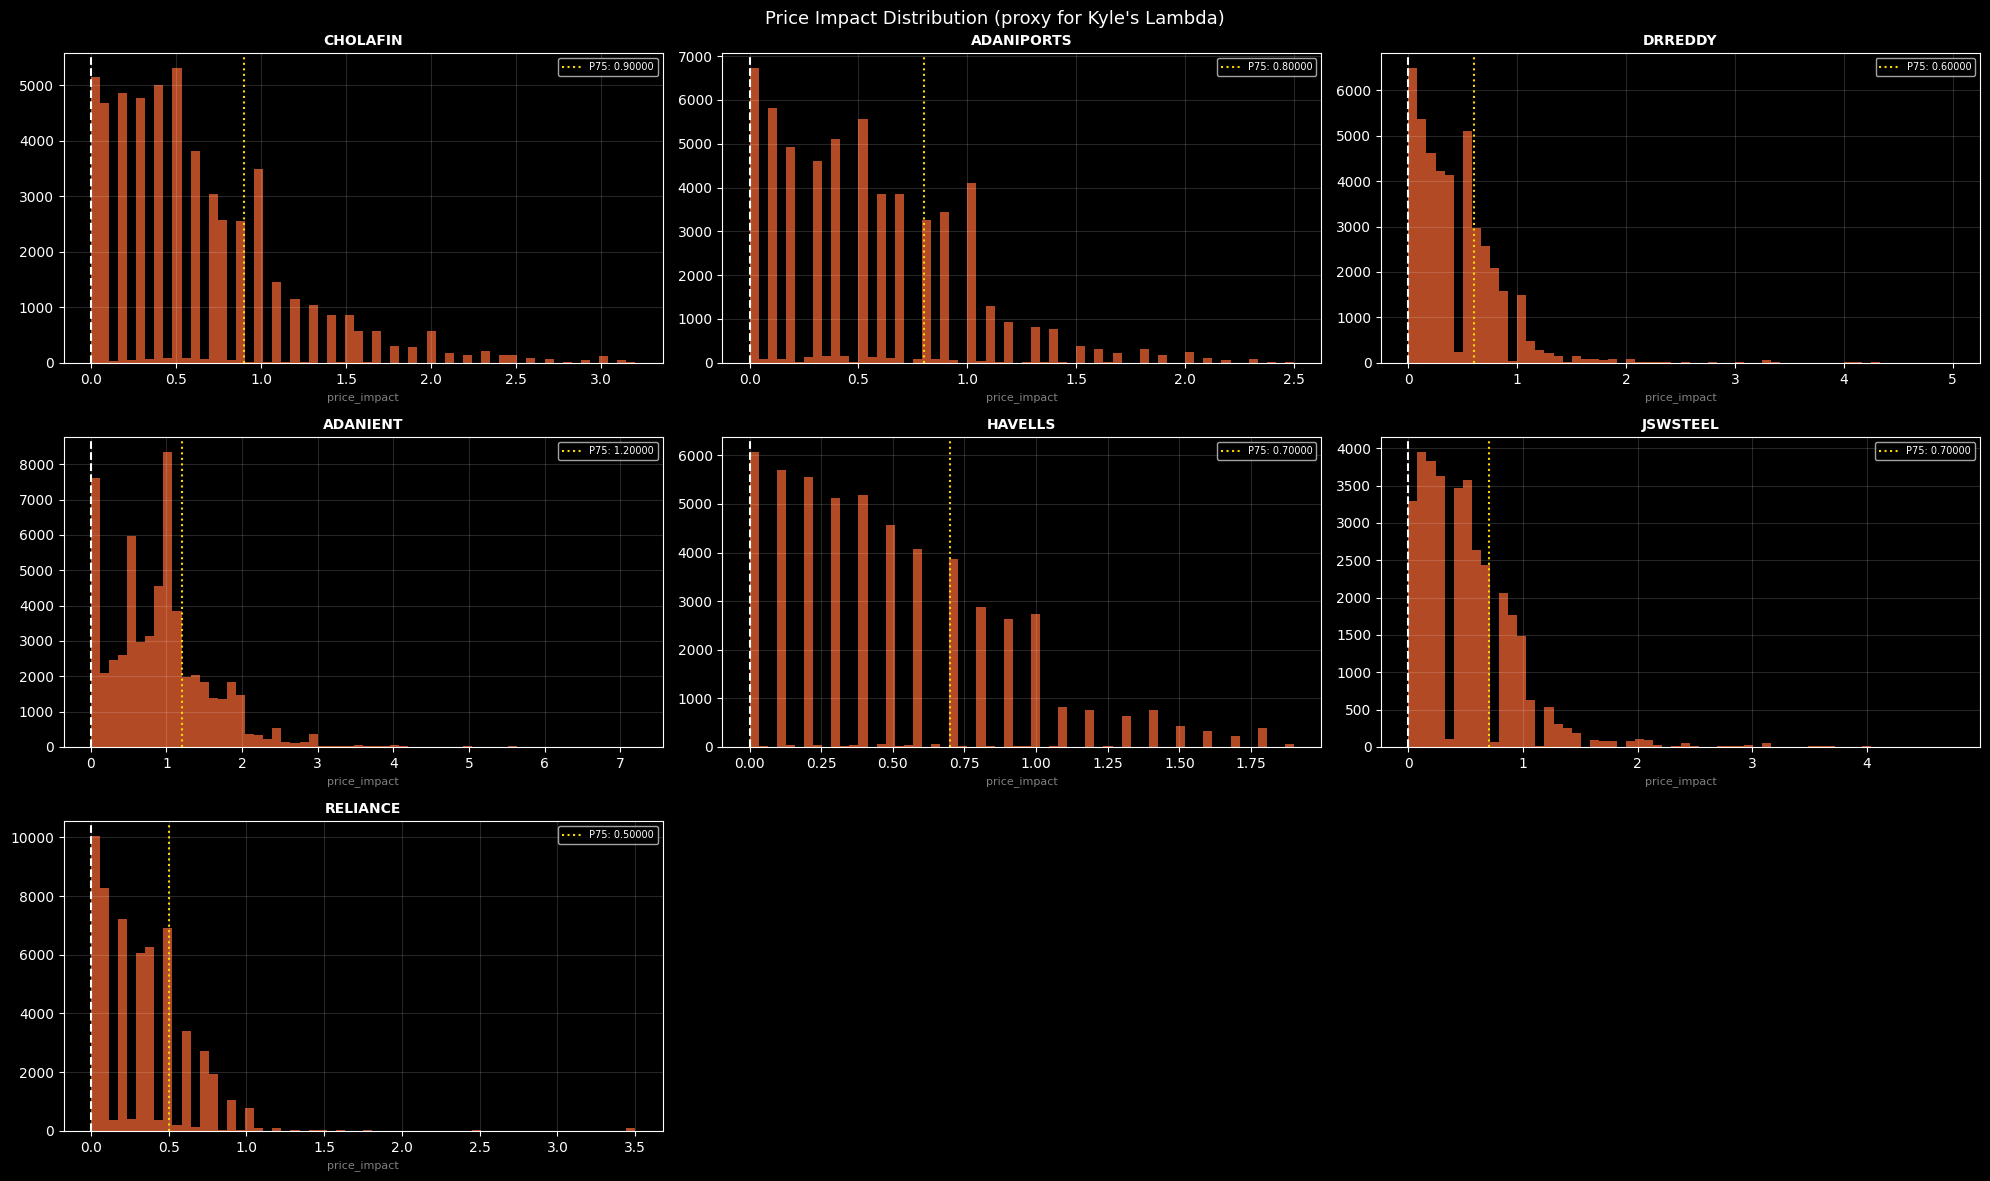


Symbol                           Median|impact|        P90   High impact%
---------------------------------------------------------------------------
CHOLAFIN26MAYFUT                       0.500000   1.300000          22.9%
ADANIPORTS26MAYFUT                     0.500000   1.100000          23.4%
DRREDDY26MAYFUT                        0.400000   0.900000          23.2%
ADANIENT26MAYFUT                       0.900000   1.800000          25.0%
HAVELLS26MAYFUT                        0.400000   1.000000          24.0%
JSWSTEEL26MAYFUT                       0.400000   1.000000          23.1%
RELIANCE26MAYFUT                       0.300000   0.700000          18.8%


In [12]:
if 'price_impact' in list(symbol_data.values())[0].columns:
    n    = len(symbol_data)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten()

    price_impact_stats = {}
    for i, (sym, df) in enumerate(symbol_data.items()):
        ax  = axes[i]
        pi  = df['price_impact'].dropna()
        pi  = pi[pi.abs() < pi.abs().quantile(0.99)]

        price_impact_stats[sym] = {
            'median_abs_impact': round(float(pi.abs().median()), 6),
            'p90_abs_impact':    round(float(pi.abs().quantile(0.90)), 6),
            'pct_high_impact':   round(float((pi.abs() > pi.abs().quantile(0.75)).mean() * 100), 1),
        }

        ax.hist(pi, bins=60, color='#ff6b35', alpha=0.7, edgecolor='none')
        ax.axvline(0, color='white', lw=1.5, ls='--')
        ax.axvline(pi.abs().quantile(0.75), color='#ffd700', lw=1.5, ls=':',
                   label=f'P75: {pi.abs().quantile(0.75):.5f}')
        ax.set_title(sym.replace('26MAYFUT', ''), color='white', fontsize=10, fontweight='bold')
        ax.set_xlabel('price_impact', color='gray', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.15)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Price Impact Distribution (proxy for Kyle\'s Lambda)',
                 fontsize=13, color='white')
    plt.tight_layout()
    plt.savefig('../findings/price_impact.png', dpi=150, bbox_inches='tight', facecolor='black')
    plt.show()

    print(f"\n{'Symbol':30s} {'Median|impact|':>16} {'P90':>10} {'High impact%':>14}")
    print('-' * 75)
    for sym, s in price_impact_stats.items():
        print(f"{sym:30s} {s['median_abs_impact']:>16.6f} "
              f"{s['p90_abs_impact']:>10.6f} {s['pct_high_impact']:>13.1f}%")
else:
    print('price_impact column not found')

## 12. Save All Findings

In [13]:
# Load kappa findings from notebook 01
kappa_path = os.path.join(FINDINGS_DIR, 'kappa_by_symbol.json')
existing   = json.loads(open(kappa_path).read()) if os.path.exists(kappa_path) else {}

findings = {}
for sym in symbol_data:
    # Best imbalance signal
    best_imb = max(
        imb_results.get(sym, {}).items(),
        key=lambda x: x[1].get('hit_rate_pct', 0),
        default=(None, {})
    )

    findings[sym] = {
        # From notebook 01
        **{k: v for k, v in existing.get(sym, {}).items()},
        # Queue depth
        'queue':          queue_stats.get(sym, {}),
        'book_profile':   book_profiles.get(sym, {}),
        # Imbalance — best performing signal
        'best_imbalance_signal':    best_imb[0],
        'best_imbalance_hit_rate':  best_imb[1].get('hit_rate_pct'),
        'imbalance_signals':        imb_results.get(sym, {}),
        # Spread / tick
        'tick':           tick_analysis.get(sym, {}),
        # Clustering
        'clustering':     cluster_results.get(sym, {}),
        # Fill windows
        'best_fill_windows': fill_windows.get(sym, []),
        'updated_at':     datetime.now().isoformat(),
    }

output_path = os.path.join(FINDINGS_DIR, 'queue_analysis.json')
with open(output_path, 'w') as f:
    json.dump(findings, f, indent=2, default=str)

print(f'Saved → {output_path}\n')
print('Summary:')
print(f"{'Symbol':30s} {'Med Q1 (L)':>11} {'Best signal':>22} {'Hit rate':>10} {'Fill windows':>14}")
print('-' * 94)
for sym, f_ in findings.items():
    q1  = f_.get('queue', {}).get('median_bid_q1_lots', 'N/A')
    sig = f_.get('best_imbalance_signal', 'N/A')
    hr  = f_.get('best_imbalance_hit_rate', 'N/A')
    nw  = len(f_.get('best_fill_windows', []))
    print(f"{sym:30s} {str(q1):>11} {str(sig):>22} {str(hr):>9}% {nw:>10} windows")

Saved → ../findings\queue_analysis.json

Summary:
Symbol                          Med Q1 (L)            Best signal   Hit rate   Fill windows
----------------------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                       1.0         imbalance_last     22.73%          9 windows
ADANIPORTS26MAYFUT                     1.0       imbalance_ma_60s     28.67%         10 windows
DRREDDY26MAYFUT                        2.0         imbalance_last     36.93%          9 windows
ADANIENT26MAYFUT                       1.0           volume_delta     31.17%          9 windows
HAVELLS26MAYFUT                        1.0       imbalance_ma_60s     20.57%          9 windows
JSWSTEEL26MAYFUT                       1.0           volume_delta     24.05%          9 windows
RELIANCE26MAYFUT                       2.0           volume_delta     27.24%          9 windows


## 13. Conclusions & Action Items

*(Fill in after running)*

### Key Questions to Answer
1. How many lots deep is bid_q1 typically? (how far back are we in queue)
2. Which time windows have best fill score? (when to trade)
3. Does any imbalance signal hit > 55%? (worth using for quote skewing)
4. How long are quiet periods? (can we cancel+rejoin at front during quiet?)
5. What % of bars have spread > 1 tick? (our best fill opportunity moments)
6. Which symbol has lowest price_impact? (safest to MM)

### Action Items by Priority
- [ ] **Time filter**: restrict trading to best_fill_windows in mm_strategy.py
- [ ] **Spread filter**: only quote when spread_zscore > 0 (wider than usual)
- [ ] **Imbalance skew**: if hit_rate > 55%, skew reservation price toward signal
- [ ] **Burst detection**: cancel+rejoin after burst clears (queue resets, get priority)
- [ ] Next: `03_realized_volatility.ipynb` — dynamic σ for better spread sizing

### Integration into mm_strategy.py
```python
import json
from pathlib import Path

_Q = json.loads((Path(__file__).parents[2] / 'research/findings/queue_analysis.json').read_text())

# In MMStrategy.on_bar(bar):

# 1. Time-of-day filter
best_windows = _Q.get(self.symbol, {}).get('best_fill_windows', [])
if best_windows and bar['ts_ist'][11:16] not in best_windows:
    return

# 2. Spread filter — only quote when spread is wider than usual
if bar.get('spread_zscore', 0) < 0:
    return

# 3. Imbalance skew — shift reservation price toward signal
imb = bar.get('imbalance_last', 0)
reservation_price = mid - self.gamma * self.sigma**2 * self.T * self.inventory
reservation_price += imb * self.tick_size * 0.5  # skew toward imbalance
```